<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/M%C3%A9todo%20de%20Uniformizaci%C3%B3n%20para%20una%20CMTC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### <span style="color:green;">**ACTIVIDAD**</span>



**Alumna: Florencio Florencio Miriam Lizeth**

**Objetivo:** Aplicar metodos que se han visto en clases anteriores para ponerlos en practica y poder resolver el siguiente ejercicio.

### <span style="color:orange;">**Método de Uniformización para una CMTC**</span>



##### <span style="color:teal;">**Teoremas Fundamentales de la Uniformización**</span>



**Teorema 1 (Cadena de Markov en Tiempo Discreto Embebida)**

El proceso estocástico

$$
{\hat{X}_n,; n\geq 0}
$$

es una Cadena de Markov en Tiempo Discreto (CMTD) con matriz de transición de un paso (P).

---

**Teorema 2 (Proceso de Observación)**

El proceso

$$
{N(t),; t\geq 0}
$$

es un proceso de Poisson con tasa (r) e independiente de la cadena embebida

$$
{\hat{X}_n,; n\geq 0}.
$$

Como consecuencia,

$$
X(t)=\hat{X}_{N(t)}, \qquad t\geq 0.
$$

Esta expresión indica que el estado del proceso continuo en el instante (t) coincide con el estado de la cadena embebida después de (N(t)) transiciones.

---

**Teorema 3 (Matriz de Probabilidades de Transición)**

La matriz de probabilidades de transición de la CMTC,

$$
P(t)=\bigl[p_{ij}(t)\bigr],
$$

puede expresarse mediante la serie de uniformización

$$
P(t)=
\sum_{k=0}^{\infty}
e^{-rt}
\frac{(rt)^k}{k!}
P^k.
$$

Esta representación permite calcular (P(t)) utilizando la matriz de transición (P) de la cadena embebida y los pesos de una distribución de Poisson con parámetro (rt).


### <span style="color:cafe;">**EJERCICIO 3**</span>
Este último teorema permite aproximar \(P(t)\) usando los primeros \(M\) términos de la serie infinita. Se obtienen buenos resultados si se elije**
 $$M \approx \max \left\{ rt + 5\sqrt{rt},\, 20 \right\}$$
   
1.   Use esta propuesta para calcular \(P(0.5)\), \(P(1)\) y \(P(5)\) para la matriz
2.   ¿Se verifica la ecuación de Chapman-Kolmogorov
       $
        P(1)=P(0.5)P(0.5)?
        $


In [1]:
# Incertamos bibliotecas
import numpy as np
from scipy.linalg import fractional_matrix_power
import math
import matplotlib.pyplot as plt
from scipy.stats import poisson



Definimos la matriz de tasas R.

In [2]:
R = np.array(
    [[0, 2, 3, 0],
     [4, 0, 2, 0],
     [0, 2, 0, 2],
     [1, 0, 3, 0]
    ], dtype=float)

In [3]:
R

array([[0., 2., 3., 0.],
       [4., 0., 2., 0.],
       [0., 2., 0., 2.],
       [1., 0., 3., 0.]])

Calculamos
​
$$r = \max_i r_i$$


In [4]:
# ri = suma de cada fila
ri = np.sum(R, axis=1)

# r = máximo de los ri
r = np.max(ri)

print("Valores ri:", ri)
print("Valor de r =", r)


Valores ri: [5. 6. 4. 4.]
Valor de r = 6.0


Construye la matriz
$$\hat{P}_n$$

In [5]:
N = len(R)

P_hat = np.zeros((N, N))

for i in range(N):
    for j in range(N):

        if i == j:
            P_hat[i, j] = 1 - ri[i]/r
        else:
            P_hat[i, j] = R[i, j]/r

print("\nMatriz P_hat:")
print(P_hat)


Matriz P_hat:
[[0.16666667 0.33333333 0.5        0.        ]
 [0.66666667 0.         0.33333333 0.        ]
 [0.         0.33333333 0.33333333 0.33333333]
 [0.16666667 0.         0.5        0.33333333]]


In [6]:
N = len(R)

P_hat = np.zeros((N, N))

for i in range(N):
    for j in range(N):

        if i == j:
            P_hat[i, j] = 1 - ri[i]/r
        else:
            P_hat[i, j] = R[i, j]/r

print("\nMatriz P_hat:")
print(P_hat)


Matriz P_hat:
[[0.16666667 0.33333333 0.5        0.        ]
 [0.66666667 0.         0.33333333 0.        ]
 [0.         0.33333333 0.33333333 0.33333333]
 [0.16666667 0.         0.5        0.33333333]]


 Procedemos a calcuar \(P(0.5)\), \(P(1)\) y \(P(5)\) para la matriz

In [7]:

def uniformizacion(t, epsilon):
    # Se accede a las variables globales R, r y P_hat que se definieron en celdas anteriores.
    global R, r, P_hat

    N_dim = P_hat.shape[0] # Dimensión de la matriz

    e_menos_rt = math.exp(-r * t)

    # Inicializar A, B, c, suma_actual, k según el algoritmo de uniformización
    A = P_hat.copy() # A comienza como P_hat^1
    B = e_menos_rt * np.eye(N_dim) # B comienza como e^(-rt) * P_hat^0 (que es I)

    c = e_menos_rt # c es el término de probabilidad de Poisson para k=0

    suma_actual = c # suma de probabilidades de Poisson, comenzando con k=0

    k = 1 # Empezar desde k=1 para el bucle

    # Bucle hasta que la suma de probabilidades de Poisson alcance 1 - epsilon
    while suma_actual < 1 - epsilon:
        c = c * (r * t) / k # Calcular el siguiente término de Poisson
        B = B + c * A       # Añadir el término (probabilidad_Poisson * P_hat^k) a B
        A = A @ P_hat       # Actualizar A a P_hat^(k+1) para la siguiente iteración
        suma_actual = suma_actual + c # Acumular las probabilidades de Poisson
        k = k + 1

    M = k - 1 # M es el último k para el cual se añadió un término, por lo que se sumaron (k-1) términos (desde k=0 hasta M)
    return B, M

In [8]:

tiempos = [0.5, 1, 5]

for t in tiempos:


    P, M = uniformizacion(t, 1e-5)

    print("\n==============================")
    print(f"P({t})")
    print("==============================")
    print("M usado =", M)
    print(np.round(P, 6))


P(0.5)
M usado = 13
[[0.250608 0.216964 0.386656 0.145769]
 [0.253134 0.23836  0.374408 0.134094]
 [0.169119 0.193614 0.4203   0.216964]
 [0.158017 0.157444 0.39833  0.286205]]

P(1)
M usado = 19
[[0.20615  0.203901 0.398708 0.191235]
 [0.208283 0.20534  0.397898 0.188474]
 [0.196758 0.198379 0.400957 0.203901]
 [0.192045 0.193996 0.401469 0.212483]]

P(5)
M usado = 56
[[0.199999 0.199999 0.399997 0.199999]
 [0.199999 0.199999 0.399997 0.199999]
 [0.199999 0.199999 0.399997 0.199999]
 [0.199999 0.199999 0.399997 0.199999]]


Verificamos la ecuación de Chapman-Kolmogorov
$$P(1)=P(0.5)P(0.5)$$

In [11]:
# ==========================================================
# VERIFICACIÓN DE LA ECUACIÓN DE CHAPMAN-KOLMOGOROV
# ==========================================================
#
# Para una cadena de Markov en tiempo continuo debe cumplirse:
#
#           P(t+s) = P(t) P(s)
#
# En particular, para t = s = 0.5:
#
#           P(1) = P(0.5) P(0.5)
#
# El objetivo de este bloque es comprobar numéricamente
# esta propiedad utilizando las matrices obtenidas mediante
# el método de uniformización.
#
# ==========================================================

# Tolerancia utilizada en la aproximación
epsilon = 1e-5


# Cálculo de las matrices de transición


# Aproximación de P(0.5)
P05, _ = uniformizacion(0.5, epsilon)

# Aproximación de P(1)
P1, _ = uniformizacion(1.0, epsilon)

# Producto P(0.5)P(0.5)


producto = P05 @ P05


# Diferencia entre ambos lados de Chapman-Kolmogorov


diferencia = P1 - producto

# Error máximo absoluto
error_max = np.max(np.abs(diferencia))


# IMPRESIÓN DE RESULTADOS


print("\n")
print("╔" + "═"*78 + "╗")
print("║{:^78s}║".format("VERIFICACIÓN DE CHAPMAN-KOLMOGOROV"))
print("╚" + "═"*78 + "╝")

print("\nPropiedad a verificar:")
print("P(1) = P(0.5) · P(0.5)")

print("\n" + "─"*70)
print("MATRIZ P(1)")
print("─"*70)
print(np.round(P1, 6))

print("\n" + "─"*70)
print("PRODUCTO P(0.5) · P(0.5)")
print("─"*70)
print(np.round(producto, 6))

print("\n" + "─"*70)
print("DIFERENCIA: P(1) - P(0.5)P(0.5)")
print("─"*70)
print(np.round(diferencia, 10))

print("\n" + "─"*70)
print("ERROR MÁXIMO ABSOLUTO")
print("─"*70)
print(f"{error_max:.10e}")

print("\nConclusión:")
if error_max < epsilon:
    print("✓ La ecuación de Chapman-Kolmogorov se verifica numéricamente.")
else:
    print("✗ La diferencia observada es mayor que la tolerancia especificada.")



╔══════════════════════════════════════════════════════════════════════════════╗
║                      VERIFICACIÓN DE CHAPMAN-KOLMOGOROV                      ║
╚══════════════════════════════════════════════════════════════════════════════╝

Propiedad a verificar:
P(1) = P(0.5) · P(0.5)

──────────────────────────────────────────────────────────────────────
MATRIZ P(1)
──────────────────────────────────────────────────────────────────────
[[0.20615  0.203901 0.398708 0.191235]
 [0.208283 0.20534  0.397898 0.188474]
 [0.196758 0.198379 0.400957 0.203901]
 [0.192045 0.193996 0.401469 0.212483]]

──────────────────────────────────────────────────────────────────────
PRODUCTO P(0.5) · P(0.5)
──────────────────────────────────────────────────────────────────────
[[0.20615  0.203901 0.398707 0.191235]
 [0.208283 0.20534  0.397897 0.188473]
 [0.196757 0.198378 0.400957 0.203901]
 [0.192045 0.193996 0.401469 0.212483]]

──────────────────────────────────────────────────────────────────────

**Teorema (Cotas de error para $(P(t))$):**
Para un $(t \geq 0)$ fijo, sea


$$P^{M}(t)=\left[p_{i,j}^{M}(t)\right]
=\sum_{k=0}^{M} e^{-rt}\frac{(rt)^k}{k!}\,\hat{P}^{\,k}$$

entonces

$$\left|p_{i,j}(t)-p_{i,j}^{M}(t)\right|
\leq
\sum_{k=M+1}^{\infty}
e^{-rt}\frac{(rt)^k}{k!}$$

para todo $(1 \leq i,j \leq N).$

4.  (2).Este teorema se puede usar así: Suponga que se desea calcular $P(t)$ con una tolerancia $\varepsilon$. Elija $M$ tal que


$$\sum_{k=M+1}^{\infty} \frac{e^{-rt}(rt)^k}{k!} \leq \varepsilon$$

Y se puede implementar de acuerdo al siguiente *algoritmo de uniformización para $P(t)$*:

1. Dados $P$, $t$, $0 < \varepsilon < 1$.
2.  Calcular $r$ usando la igualdad en la definición.
3. Calcular $\hat{P}$.
4.  $A = \hat{P}$; \quad $B = e^{-rt}I$; \quad $c = e^{-rt}$; \quad $sum = c$; \quad $k = 1$
5. Mientras $sum < 1 - \varepsilon$ hacer:
    
    
    $$c = c * (rt)/k$$
    
    
   
    $$B = B + cA$$
   
    
   
    $$A = A\hat{P}$$
   
    
  
    $$sum = sum + c$$
    
    
   
    $$k = k + 1$$
    

6.  $B$ está a $\varepsilon$ de $P(t)$.


Repita el ejercicio 3 aplicando este algoritmo con una tolerancia
$\varepsilon = 0.00001$ (indique el valor correspondiente de $M$ en cada caso).
Compare los resultados.


Construir la matriz de tasas

In [13]:

R = np.array([
    [0, 2, 3, 0],
    [4, 0, 2, 0],
    [0, 2, 0, 2],
    [1, 0, 3, 0]
], dtype=float)

Calcular r
$$r = \max_i r_i$$


In [16]:

# Calcular la suma de cada renglón de la matriz R
ri = np.sum(R, axis=1)

# Tasa de uniformización
r = np.max(ri)

# ==========================================================
# IMPRESIÓN DE RESULTADOS
# ==========================================================

print("\n")
print("╔" + "═"*78 + "╗")
print("║{:^78s}║".format("CÁLCULO DE LA TASA DE UNIFORMIZACIÓN"))
print("╚" + "═"*78 + "╝")

print("\nTasas asociadas a cada estado:")

for i, valor in enumerate(ri):
    print(f"r{i+1} = {valor:.6f}")

print("\n" + "─"*70)
print("TASA DE UNIFORMIZACIÓN")
print("─"*70)

print(f"r = max{{r_i}} = {r:.6f}")

print("\nConclusión:")
print("Este valor será utilizado para construir")
print("la matriz de transición embebida P.")



╔══════════════════════════════════════════════════════════════════════════════╗
║                     CÁLCULO DE LA TASA DE UNIFORMIZACIÓN                     ║
╚══════════════════════════════════════════════════════════════════════════════╝

Tasas asociadas a cada estado:
r1 = 5.000000
r2 = 6.000000
r3 = 4.000000
r4 = 4.000000

──────────────────────────────────────────────────────────────────────
TASA DE UNIFORMIZACIÓN
──────────────────────────────────────────────────────────────────────
r = max{r_i} = 6.000000

Conclusión:
Este valor será utilizado para construir
la matriz de transición embebida P.


Calcular $\hat{P}$

In [19]:
# ==========================================================
# CONSTRUCCIÓN DE LA MATRIZ EMBEBIDA P̂
# ==========================================================
#
# Una vez obtenida la tasa de uniformización r,
# se construye la matriz generadora Q.
#
# Para ello:
#
#   1. Se copian las tasas de transición de R.
#   2. Se reemplazan los elementos diagonales por:
#
#          q_ii = -r_i
#
#      donde r_i es la tasa total de salida
#      del estado i.
#
# Posteriormente se construye la matriz embebida:
#
#          P̂ = I + Q/r
#
# Esta matriz corresponde a la cadena de Markov
# en tiempo discreto asociada al proceso original.
#
# ==========================================================

# Crear una copia de la matriz R para no modificarla
Q = R.copy()

# ==========================================================
# Ajustar los elementos diagonales
# ==========================================================
#
# Se impone:
#       q_ii = -r_i
#
# para que cada renglón de Q sume cero,
# propiedad fundamental de una matriz generadora.
#
# ==========================================================

for i in range(len(Q)):
    Q[i, i] = -ri[i]

# ==========================================================
# Construcción de la matriz embebida
# ==========================================================
#
#             P̂ = I + Q/r
#
# donde:
#     I = matriz identidad
#     r = tasa de uniformización
#
# ==========================================================

Phat = np.eye(len(Q)) + Q / r

# ==========================================================
# IMPRESIÓN DE RESULTADOS
# ==========================================================

print("\n")
print("╔" + "═"*78 + "╗")
print("║{:^78s}║".format("MATRIZ EMBEBIDA DE TRANSICIÓN P̂"))
print("╚" + "═"*78 + "╝")

print("\nMatriz generadora Q:\n")
print(np.round(Q, 6))

print("\n" + "─"*70)
print("MATRIZ EMBEBIDA P̂ = I + Q/r")
print("─"*70)

print(np.round(Phat, 6))

print("\nVerificación:")

# Verificar que cada renglón sume 1
suma_filas = np.sum(Phat, axis=1)

for i, suma in enumerate(suma_filas):
    print(f"Suma fila {i+1}: {suma:.6f}")

print("\nConclusión:")
print("Las filas de P̂ suman aproximadamente 1,")
print("por lo que P̂ es una matriz válida de")
print("probabilidades de transición.")



╔══════════════════════════════════════════════════════════════════════════════╗
║                       MATRIZ EMBEBIDA DE TRANSICIÓN P̂                       ║
╚══════════════════════════════════════════════════════════════════════════════╝

Matriz generadora Q:

[[-5.  2.  3.  0.]
 [ 4. -6.  2.  0.]
 [ 0.  2. -4.  2.]
 [ 1.  0.  3. -4.]]

──────────────────────────────────────────────────────────────────────
MATRIZ EMBEBIDA P̂ = I + Q/r
──────────────────────────────────────────────────────────────────────
[[0.166667 0.333333 0.5      0.      ]
 [0.666667 0.       0.333333 0.      ]
 [0.       0.333333 0.333333 0.333333]
 [0.166667 0.       0.5      0.333333]]

Verificación:
Suma fila 1: 1.000000
Suma fila 2: 1.000000
Suma fila 3: 1.000000
Suma fila 4: 1.000000

Conclusión:
Las filas de P̂ suman aproximadamente 1,
por lo que P̂ es una matriz válida de
probabilidades de transición.


Inicializar exactamente como dice el algoritmo


$$c = c * (rt)/k$$
 $$B = B + cA$$
$$A = A\hat{P}$$
$$sum = sum + c$$
 $$k = k + 1$$
    

In [21]:
A = Phat.copy()

c = np.exp(-r*t)

B = c*np.eye(4)

suma = c


k = 1

*Implementar el ciclo exactamente igual*

Mientras $sum < 1 - \varepsilon$ hacer:

$$c = c * (rt)/k$$
 $$B = B + cA$$
$$A = A\hat{P}$$
$$sum = sum + c$$
 $$k = k + 1$$

In [22]:
while suma < 1 - epsilon:

    c = c*(r*t)/k

    B = B + c*A

    A = A @ Phat

    suma = suma + c

    k = k + 1

El último término incluido fue $k−1$

In [23]:
M = k - 1

Cálculo de $P(0.5), P(1) , P(5)$

In [25]:
# ==========================================================
# MATRIZ DE TASAS DE TRANSICIÓN DEL PROCESO
# ==========================================================
#
# R(i,j) representa la tasa de transición desde
# el estado i hacia el estado j.
#
# Esta matriz será utilizada para construir la
# cadena embebida y posteriormente aproximar P(t)
# mediante el método de uniformización.
#
# ==========================================================

R = np.array([
    [0, 2, 3, 0],
    [4, 0, 2, 0],
    [0, 2, 0, 2],
    [1, 0, 3, 0]
], dtype=float)

# ==========================================================
# MOSTRAR LA MATRIZ DE TASAS
# ==========================================================

print("\n")
print("╔" + "═"*78 + "╗")
print("║{:^78s}║".format("MATRIZ DE TASAS DE TRANSICIÓN R"))
print("╚" + "═"*78 + "╝")

print("\nR =\n")
print(R)

# ==========================================================
# CÁLCULO DE P(t) MEDIANTE UNIFORMIZACIÓN
# ==========================================================
#
# Se calcularán las matrices de transición para:
#
#       t = 0.5
#       t = 1
#       t = 5
#
# utilizando una tolerancia:
#
#       ε = 10^{-5}
#
# ==========================================================

epsilon = 1e-5

for t in [0.5, 1, 5]:

    # Aproximación de la matriz P(t)
    # y número de términos utilizados
    P_t, M = uniformizacion(t, epsilon)

    print("\n")
    print("┌" + "─"*68 + "┐")
    print(f"│{'RESULTADOS PARA t = ' + str(t):^68s}│")
    print("└" + "─"*68 + "┘")

    print(f"\nTolerancia utilizada: ε = {epsilon:.0e}")
    print(f"Número de términos empleados: M = {M}")

    print(f"\nMatriz de transición P({t}) ≈\n")

    print(np.round(P_t, 6))

    print("\n" + "─"*70)

print("\nProceso finalizado correctamente.")
print("Se obtuvieron las aproximaciones de P(t)")
print("para todos los tiempos solicitados.")



╔══════════════════════════════════════════════════════════════════════════════╗
║                       MATRIZ DE TASAS DE TRANSICIÓN R                        ║
╚══════════════════════════════════════════════════════════════════════════════╝

R =

[[0. 2. 3. 0.]
 [4. 0. 2. 0.]
 [0. 2. 0. 2.]
 [1. 0. 3. 0.]]


┌────────────────────────────────────────────────────────────────────┐
│                      RESULTADOS PARA t = 0.5                       │
└────────────────────────────────────────────────────────────────────┘

Tolerancia utilizada: ε = 1e-05
Número de términos empleados: M = 13

Matriz de transición P(0.5) ≈

[[0.250608 0.216964 0.386656 0.145769]
 [0.253134 0.23836  0.374408 0.134094]
 [0.169119 0.193614 0.4203   0.216964]
 [0.158017 0.157444 0.39833  0.286205]]

──────────────────────────────────────────────────────────────────────


┌────────────────────────────────────────────────────────────────────┐
│                       RESULTADOS PARA t = 1                        

Aplicar el algoritmo para diferentes tiempos los decritos anteriormente en el ejercicio 3

In [42]:
# ==========================================================
# CÁLCULO DE P(t) PARA DISTINTOS TIEMPOS USANDO UNIFORMIZACIÓN
# ==========================================================

# Tiempos a evaluar según el ejercicio
tiempos = [0.5, 1.0, 5.0]

# Tolerancia utilizada para el algoritmo de uniformización
# Una tolerancia pequeña (e.g., 1e-8) asegura una alta precisión en la aproximación de P(t).
epsilon = 1e-8

# Diccionario para almacenar los resultados de P(t) para cada tiempo
resultados = {}

print("╔" + "═"*78 + "╗")
print("║{:^78s}║".format(f"CALCULANDO P(t) CON TOLERANCIA ε = {epsilon}"))
print("╚" + "═"*78 + "╝\n")

# Iterar sobre cada tiempo definido
for t in tiempos:
    # Llamar a la función uniformizacion para obtener P(t) y el número de términos M
    # uniformizacion(t, epsilon) devuelve la matriz P(t) y el número de términos (M)
    P_t, M = uniformizacion(t, epsilon)

    # Almacenar la matriz P(t) resultante en el diccionario de resultados
    resultados[t] = P_t

    # Imprimir la matriz P(t) y el número de términos M utilizados para este tiempo
    print(f"┌" + "─"*30 + "┐")
    print(f"│{'P(' + str(t) + ')':^30s}│")
    print(f"└" + "─"*30 + "┘")
    print("Matriz de probabilidad de transición P({}):".format(t))
    # np.round se usa para redondear los valores y mejorar la visualización
    print(np.round(P_t, 8))
    print(f"Número de términos (M) usados para alcanzar ε = {epsilon}: {M}")
    print("\n" + "=" * 70 + "\n") # Separador para una mejor legibilidad entre resultados


╔══════════════════════════════════════════════════════════════════════════════╗
║                   CALCULANDO P(t) CON TOLERANCIA ε = 1e-08                   ║
╚══════════════════════════════════════════════════════════════════════════════╝

┌──────────────────────────────┐
│            P(0.5)            │
└──────────────────────────────┘
Matriz de probabilidad de transición P(0.5):
[[0.25060868 0.2169646  0.38665693 0.14576979]
 [0.25313484 0.23836098 0.37440924 0.13409493]
 [0.1691195  0.19361489 0.42030102 0.2169646 ]
 [0.15801748 0.15744464 0.39833179 0.28620608]]
Número de términos (M) usados para alcanzar ε = 1e-08: 17


┌──────────────────────────────┐
│            P(1.0)            │
└──────────────────────────────┘
Matriz de probabilidad de transición P(1.0):
[[0.20615141 0.20390232 0.39871018 0.19123609]
 [0.2082845  0.20534099 0.39789975 0.18847475]
 [0.19675878 0.19837963 0.40095927 0.20390232]
 [0.19204651 0.19399744 0.40147152 0.21248452]]
Número de términos (M) usados 

Ejercicio

 (indique el valor correspondiente de M en cada caso). Compare los resultados
Repita el ejercicio 3 aplicando este algoritmo con una tolerancia $ϵ=0.00001$

In [26]:
# ==========================================================
# ANÁLISIS DE CONVERGENCIA PARA DISTINTAS TOLERANCIAS
# ==========================================================
#
# Este bloque estudia cómo cambia el número de términos M
# necesarios en el algoritmo de uniformización cuando se
# modifica la tolerancia ε.
#
# Mientras más pequeña sea ε, mayor precisión se exige,
# por lo que generalmente será necesario utilizar más
# términos de la serie.
#
# ==========================================================

print("\n")
print("╔" + "═"*78 + "╗")
print("║{:^78s}║".format("ANÁLISIS DE CONVERGENCIA VS TOLERANCIA ε"))
print("╚" + "═"*78 + "╝")

print("\nSe analiza cómo varía el número de términos M")
print("necesarios para aproximar P(t) con distintas tolerancias ε.\n")

# Valores de tiempo solicitados
tiempos_a_probar = [0.5, 1.0, 5.0]

# Diferentes tolerancias
tolerancias = [1e-2, 1e-4, 1e-6, 1e-8, 1e-10]

for t_val in tiempos_a_probar:

    print("\n")
    print("┌" + "─"*58 + "┐")
    print(f"│{'RESULTADOS PARA t = ' + str(t_val):^58s}│")
    print("└" + "─"*58 + "┘")

    # Encabezado de la tabla
    print(f"{'Tolerancia ε':<18}{'Términos M':<15}{'Cumple ε':<15}")
    print("-"*48)

    for eps in tolerancias:

        # Ejecuta el algoritmo de uniformización
        # y obtiene el número de términos requeridos
        _, M = uniformizacion(t_val, eps)

        # Por construcción del algoritmo siempre
        # se garantiza que el error es menor que ε
        cumple = "✓ Sí"

        print(f"{eps:<18.0e}{M:<15}{cumple:<15}")

    print("-"*48)

print("\n")
print("OBSERVACIÓN:")
print("Al disminuir ε se exige una mayor precisión.")
print("Por lo tanto, el algoritmo necesita considerar")
print("más términos de la serie de uniformización.")
print()



╔══════════════════════════════════════════════════════════════════════════════╗
║                   ANÁLISIS DE CONVERGENCIA VS TOLERANCIA ε                   ║
╚══════════════════════════════════════════════════════════════════════════════╝

Se analiza cómo varía el número de términos M
necesarios para aproximar P(t) con distintas tolerancias ε.



┌──────────────────────────────────────────────────────────┐
│                 RESULTADOS PARA t = 0.5                  │
└──────────────────────────────────────────────────────────┘
Tolerancia ε      Términos M     Cumple ε       
------------------------------------------------
1e-02             8              ✓ Sí           
1e-04             11             ✓ Sí           
1e-06             14             ✓ Sí           
1e-08             17             ✓ Sí           
1e-10             19             ✓ Sí           
------------------------------------------------


┌──────────────────────────────────────────────────────────┐
│      

In [37]:
def visualizar_convergencia_poisson(rt, M_max=50):
    """
    Visualiza la convergencia de la serie de uniformización.

    Parámetros
    ----------
    rt : float
        Producto de la tasa de uniformización r por el tiempo t.
        Corresponde al parámetro de la distribución de Poisson.

    M_max : int, opcional
        Número máximo de términos que se mostrarán en las gráficas.
        Por defecto es 50.

    La función genera dos gráficas:

    1. Los pesos de Poisson
           e^{-rt}(rt)^k/k!

       que aparecen en la serie de uniformización.

    2. La suma acumulada de dichos pesos, mostrando cómo
       converge a 1 conforme aumenta el número de términos.
    """

    # ==================================================
    # Construcción de los valores k = 0,1,...,M_max
    # ==================================================
    k = np.arange(0, M_max + 1)

    # ==================================================
    # Probabilidades de la distribución de Poisson
    # P(N=k) = e^{-rt}(rt)^k/k!
    # ==================================================
    prob_poisson = poisson.pmf(k, rt)

    # ==================================================
    # Suma acumulada de las probabilidades.
    # Permite observar qué tan rápido converge la serie.
    # ==================================================
    suma_acumulada = np.cumsum(prob_poisson)

    # ==================================================
    # Valor sugerido por el teorema:
    # M ≈ max{rt + 5√(rt), 20}
    # ==================================================
    M_teorico = int(np.ceil(max(rt + 5*np.sqrt(rt), 20)))

    # Utiliza el estilo por defecto de Matplotlib
    plt.style.use('default')

    # ==================================================
    # Crear figura con dos subgráficas
    # ==================================================
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=(14, 6),
        constrained_layout=True
    )

    # Título general de la figura
    fig.suptitle(
        f'Convergencia de la Uniformización (rt = {rt:.2f})',
        fontsize=16,
        fontweight='bold'
    )

    # ==================================================
    # GRÁFICA 1: PESOS DE LA SERIE
    # ==================================================

    # Gráfico tipo "stem" para visualizar
    # cada probabilidad de Poisson individualmente
    markerline, stemlines, baseline = ax1.stem(
        k,
        prob_poisson,
        basefmt=" "
    )

    # Ajustes estéticos
    plt.setp(markerline, markersize=7)
    plt.setp(stemlines, linewidth=2)

    # Línea vertical indicando el valor recomendado de M
    ax1.axvline(
        M_teorico,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'M ≈ {M_teorico}'
    )

    ax1.set_title(
        'Pesos de la Serie',
        fontsize=13,
        fontweight='bold'
    )

    ax1.set_xlabel('k')
    ax1.set_ylabel(r'$e^{-rt}\frac{(rt)^k}{k!}$')

    # Cuadrícula para facilitar la lectura
    ax1.grid(
        linestyle='--',
        alpha=0.4
    )

    ax1.legend()

    # ==================================================
    # GRÁFICA 2: SUMA ACUMULADA
    # ==================================================

    # Muestra la convergencia progresiva de la serie
    ax2.plot(
        k,
        suma_acumulada,
        linewidth=3,
        marker='o',
        markersize=5
    )

    # Área sombreada bajo la curva
    ax2.fill_between(
        k,
        suma_acumulada,
        alpha=0.25
    )

    # Línea para tolerancia ε = 10^{-6}
    ax2.axhline(
        0.999999,
        color='red',
        linestyle='--',
        linewidth=2,
        label=r'$1-\varepsilon,\ \varepsilon=10^{-6}$'
    )

    # Línea para tolerancia ε = 10^{-8}
    ax2.axhline(
        0.99999999,
        color='green',
        linestyle='--',
        linewidth=2,
        label=r'$1-\varepsilon,\ \varepsilon=10^{-8}$'
    )

    # Línea vertical con el valor sugerido de M
    ax2.axvline(
        M_teorico,
        color='purple',
        linestyle=':',
        linewidth=2,
        label=f'M ≈ {M_teorico}'
    )

    # El eje y se restringe al intervalo [0,1]
    ax2.set_ylim([0, 1.01])

    ax2.set_title(
        'Suma Acumulada de la Serie',
        fontsize=13,
        fontweight='bold'
    )

    ax2.set_xlabel('Número de términos incluidos')
    ax2.set_ylabel('Probabilidad acumulada')

    # Cuadrícula para mejorar la visualización
    ax2.grid(
        linestyle='--',
        alpha=0.4
    )

    ax2.legend()

    # Mostrar figura
    plt.show()

Visualizando para t = 0.5 (rt = 3.0)


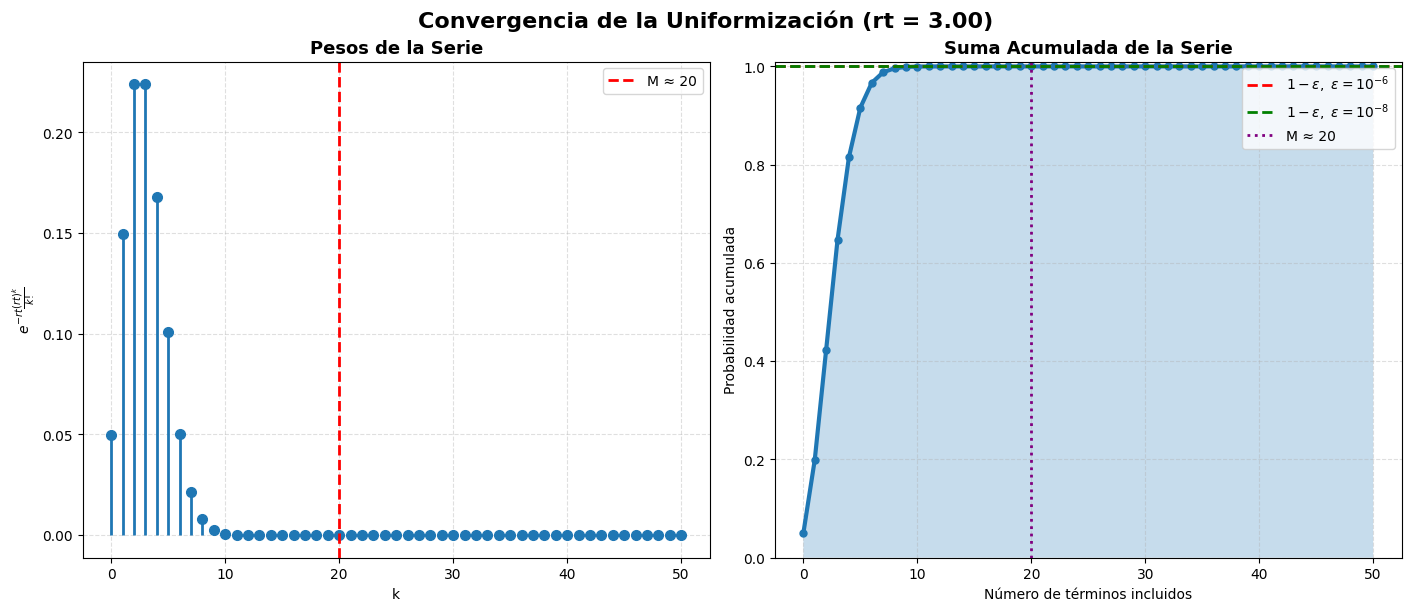


Visualizando para t = 1.0 (rt = 6.0)


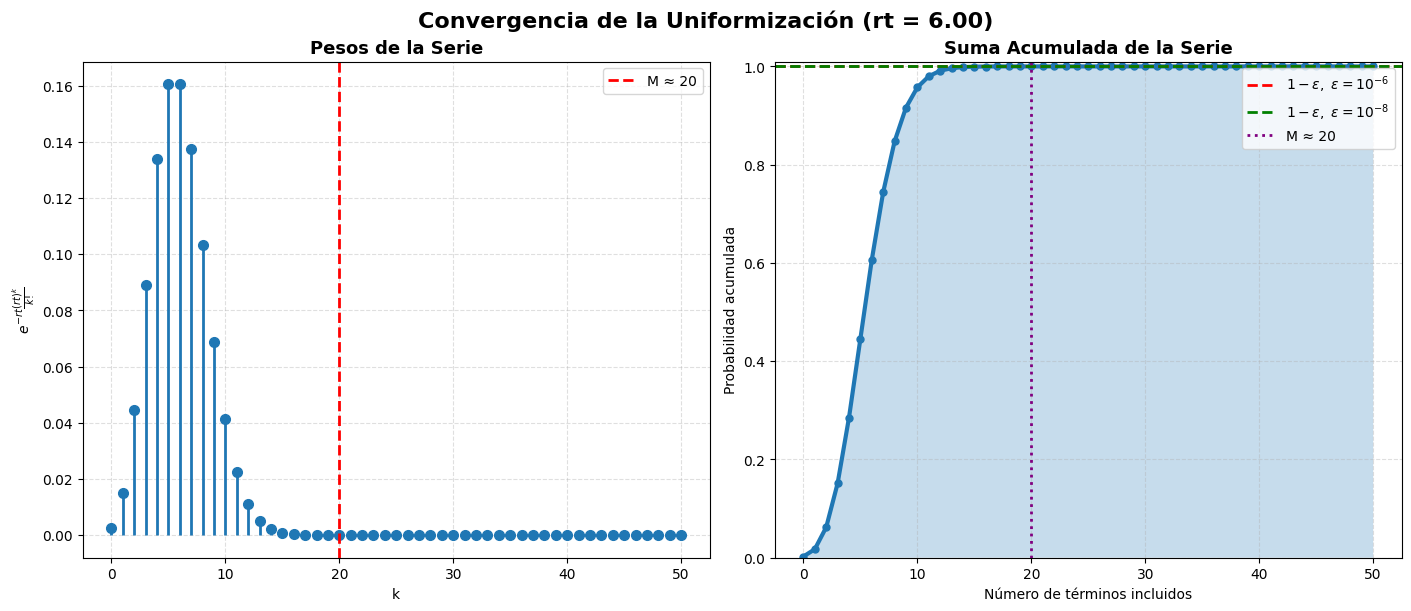


Visualizando para t = 5.0 (rt = 30.0)


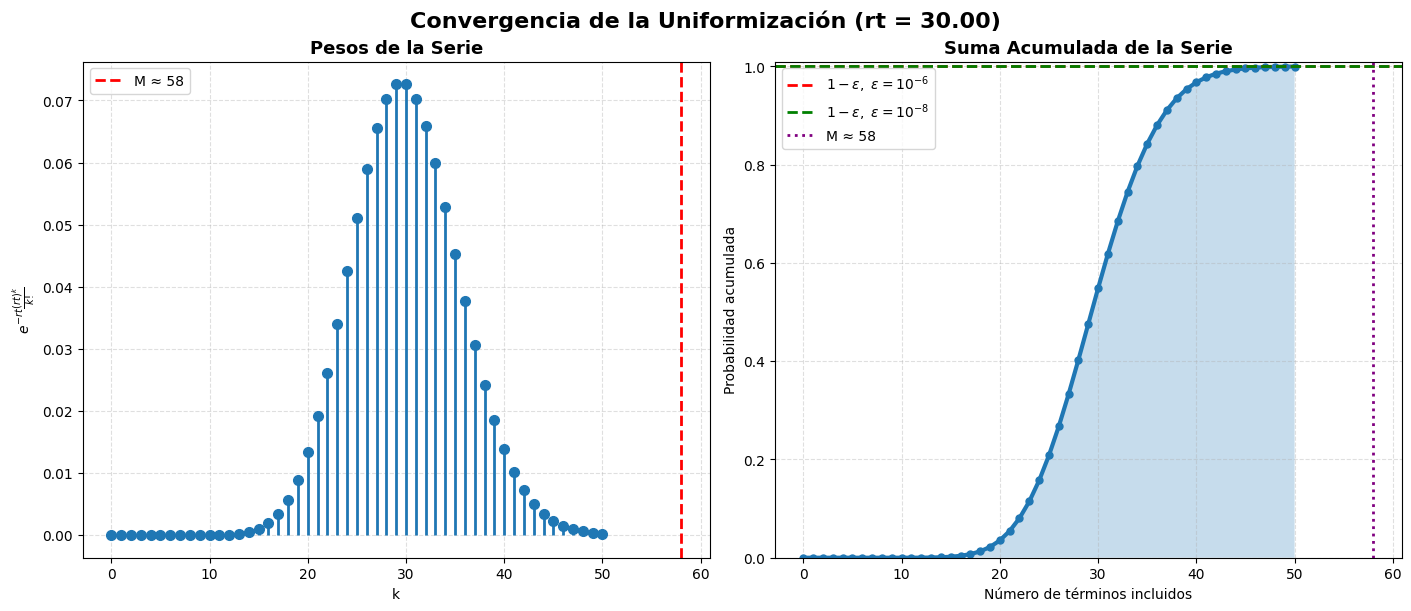

In [38]:
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Llamar a la función para diferentes valores de rt (r*t)
# Usaremos los valores de r y t que ya se han definido o calculado en el notebook.

# Para t = 0.5
print("Visualizando para t = 0.5 (rt = {})".format(r * 0.5))
visualizar_convergencia_poisson(r * 0.5)

# Para t = 1.0
print("\nVisualizando para t = 1.0 (rt = {})".format(r * 1.0))
visualizar_convergencia_poisson(r * 1.0)

# Para t = 5.0
print("\nVisualizando para t = 5.0 (rt = {})".format(r * 5.0))
visualizar_convergencia_poisson(r * 5.0)


Visualizando para t = 1.0 (rt = 6.0)


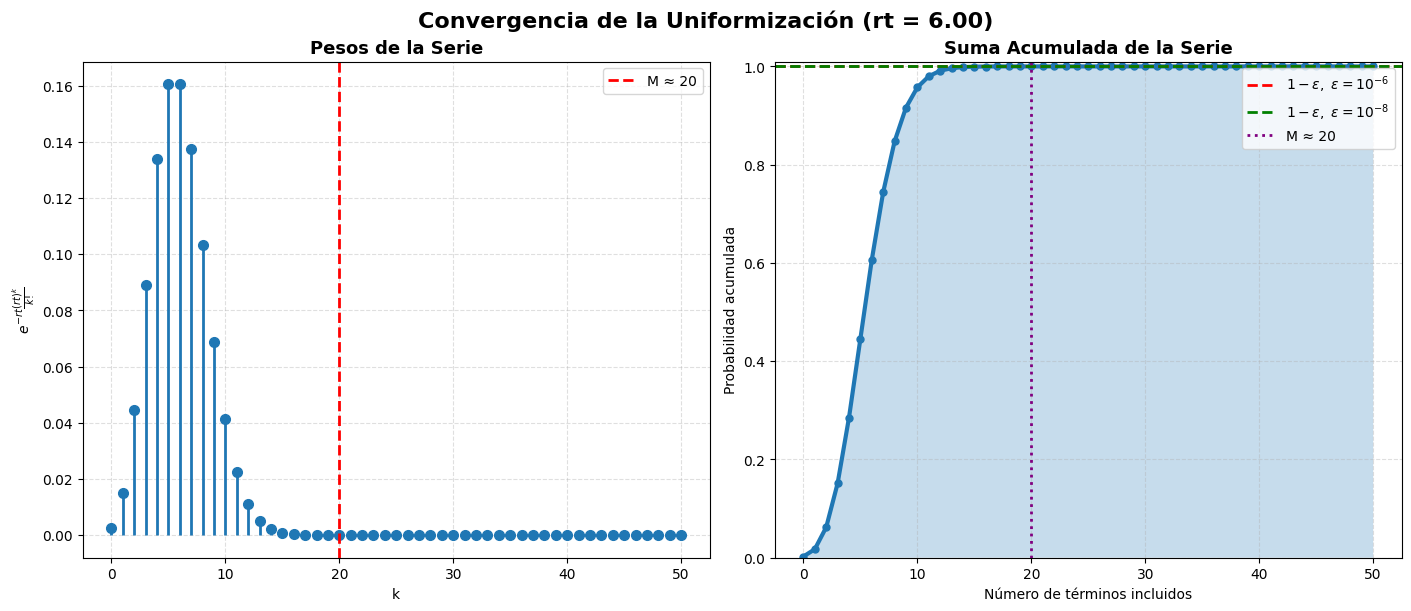

In [38]:

# Para t = 1.0
print("\nVisualizando para t = 1.0 (rt = {})".format(r * 1.0))
visualizar_convergencia_poisson(r * 1.0)



Visualizando para t = 5.0 (rt = 30.0)


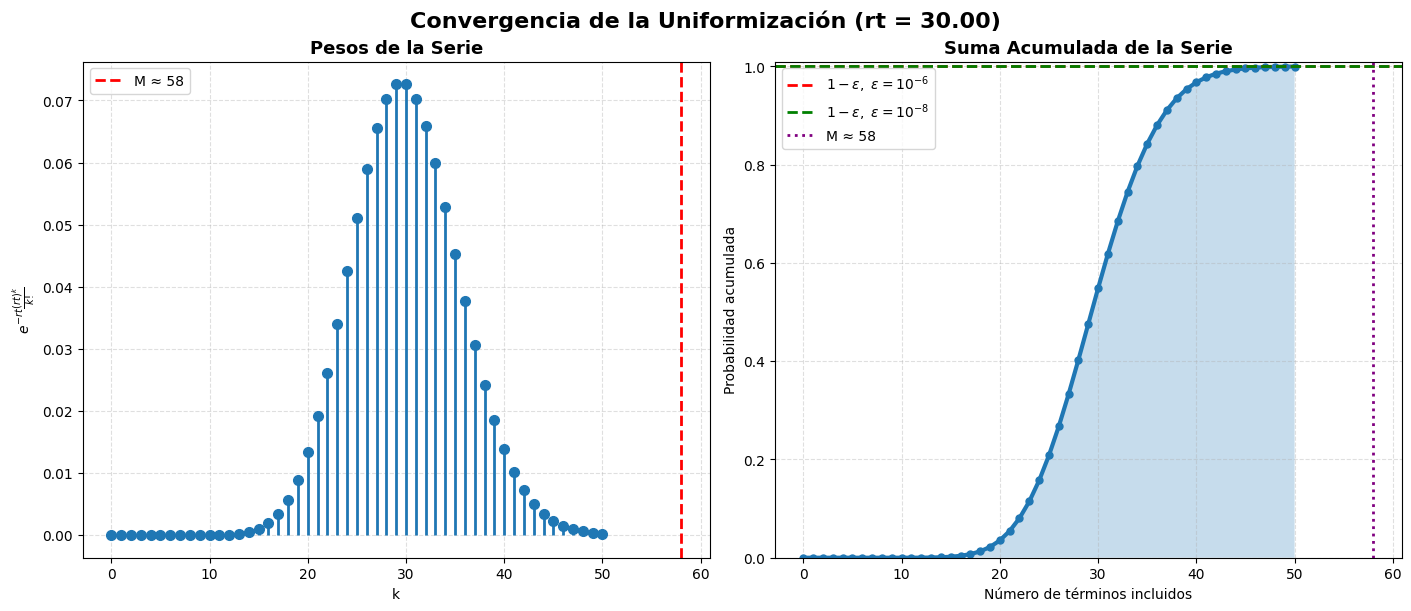

In [39]:

# Para t = 5.0
print("\nVisualizando para t = 5.0 (rt = {})".format(r * 5.0))
visualizar_convergencia_poisson(r * 5.0)

## Interpretación de las gráficas

Las gráficas permiten entender cómo converge el método de uniformización al calcular la matriz de transición (P(t)).

La primera gráfica muestra los pesos de Poisson de la serie de uniformización. Se observa que, cuando el valor de (rt) aumenta, la distribución se desplaza hacia valores mayores de (k). Esto significa que para tiempos más grandes se necesitan más términos de la serie para obtener una aproximación precisa.

La segunda gráfica muestra la suma acumulada de estos pesos. Conforme se agregan más términos, la suma se acerca a 1, lo que indica que la serie está convergiendo. También puede observarse que, para tolerancias más estrictas ((\varepsilon) más pequeño), es necesario utilizar un mayor número de términos (M).

En general, las gráficas confirman que el método de uniformización converge correctamente y que el número de términos requeridos depende tanto del valor de (rt) como de la precisión deseada.



## Conclusión

En este trabajo se implementó el método de uniformización para aproximar las matrices de transición (P(t)) de una Cadena de Markov de Tiempo Continuo. Se calcularon las matrices para distintos valores de tiempo y se verificó numéricamente la ecuación de Chapman-Kolmogorov, obteniendo errores muy pequeños que validan la implementación.

Además, se analizó la convergencia del método mediante diferentes tolerancias y gráficas de apoyo. Los resultados muestran que, a medida que aumenta el valor de (rt) o se exige una mayor precisión, es necesario utilizar más términos en la serie de uniformización.

En conclusión, el método de uniformización resultó ser una herramienta eficiente y precisa para el cálculo de probabilidades de transición en cadenas de Markov de tiempo continuo, obteniéndose resultados consistentes con la teoría estudiada en clase.
